In [1]:
import dowhy.gcm as gcm
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import numpy.random as npr
import pandas as pd
import umap
import xmltodict
from dowhy.gcm.causal_mechanisms import AdditiveNoiseModel
from dowhy.gcm.causal_models import InvertibleStructuralCausalModel
from dowhy.gcm.ml import create_polynom_regressor
from dowhy.gcm.stochastic_models import ScipyDistribution, BayesianGaussianMixtureDistribution
from scipy import stats

from modeling.cbn import MonteCarloCBN
from modeling.models import SumModel

npr.seed(42)

### Data processing

In [2]:
raw_data = pd.read_pickle('./data/rnd_proprio_spring-act_steps-1k_fskip-50.pkl')
data_proprio = raw_data.filter(regex=r'^(act:|joint:.*pos)')

In [3]:
with open('../../MIMo/mimoEnv/assets/mimo/MIMo_meta.xml', 'rb') as f:
    motors = xmltodict.parse(f)['mujoco']['actuator']['motor']

actuators = [
    col
    for col in raw_data.columns
    if col.startswith('act:')
]

act_joints = {
    act: f'joint:{motor["@joint"].removeprefix("robot:")}'
    for motor in motors
    if (act := motor['@name']) in actuators
}
joints = list(act_joints.values())

act_limits = {
    act: tuple(
        map(
            lambda force: float(force),
            motor['@forcerange'].split(' ')
        )
    )
    for motor in motors
    if (act := motor['@name']) in actuators
}

act_dpos = [
    (act, f'{act_joints[act]}.dpos')
    for act in actuators
]
dpos_qpos1 = [
    (f'{joint}.dpos', f'{joint}.pos1')
    for joint in joints
]
qpos0_qpos1 = [
    (f'{joint}.pos0', f'{joint}.pos1')
    for joint in joints
]

In [4]:
def traverse_dict(x: dict | list):
    if isinstance(x, list):
        for item in x:
            if isinstance(item, dict):
                yield from traverse_dict(item)

    elif isinstance(x, dict):
        is_leaf = True

        for key, value in x.items():
            if isinstance(value, (dict, list)):
                is_leaf = False

            if key == 'joint':
                if isinstance(value, dict):
                    yield value
                elif isinstance(value, list):
                    yield from traverse_dict(value)

            elif key == 'body':
                yield from traverse_dict(value)

        if is_leaf:
            yield x


In [5]:
with open('../../MIMo/mimoEnv/assets/mimo/MIMo_model.xml', 'rb') as f:
    mimo_model = xmltodict.parse(f)['mujoco']['body']

joint_data = list(traverse_dict(mimo_model))
joint_limits = {
    f'joint:{joint["@name"].removeprefix("robot:")}': tuple(
        map(
            lambda angle: np.deg2rad(float(angle)),
            joint['@range'].split(' ')
        )
    )
    for joint in joint_data
}
dpos_limits = {
    f'{joint}.dpos': (q_min - q_max, q_max - q_min)
    for joint, (q_min, q_max) in joint_limits.items()
}

### CBN definition


In [6]:
proprio_G = nx.DiGraph([
    *act_dpos,
    *dpos_qpos1,
    *qpos0_qpos1
])
proprio_M = InvertibleStructuralCausalModel(proprio_G)

In [7]:
for act in actuators:
    loc, loc_scale = act_limits[act]
    scale = loc_scale - loc

    proprio_M.set_causal_mechanism(
        target_node=act,
        # mechanism=EmpiricalDistribution()
        mechanism=ScipyDistribution(stats.uniform, loc=loc, scale=scale),
    )

for joint in joints:
    loc, loc_scale = joint_limits[joint]
    scale = loc_scale - loc

    proprio_M.set_causal_mechanism(
        target_node=f'{joint}.pos0',
        # mechanism=EmpiricalDistribution()
        mechanism=ScipyDistribution(stats.uniform, loc=loc, scale=scale)
    )
    proprio_M.set_causal_mechanism(
        target_node=f'{joint}.dpos',
        mechanism=AdditiveNoiseModel(
            prediction_model=create_polynom_regressor(degree=2),
            # noise_model=EmpiricalDistribution(),
            noise_model=BayesianGaussianMixtureDistribution()
        )
    )
    proprio_M.set_causal_mechanism(
        target_node=f'{joint}.pos1',
        mechanism=AdditiveNoiseModel(
            prediction_model=SumModel(joint_limits[joint]),
            noise_model=ScipyDistribution(stats.uniform, loc=0, scale=0)
        )
    )

In [8]:
cbn = MonteCarloCBN(
    untrained_scm=proprio_M,
    limits={
        **act_limits,
        # **{
        #     f'{joint}.{attr}': limit
        #     for joint, limit in joint_limits.items()
        #     for attr in ('pos0', 'pos1')
        # },
        # **dpos_limits
    }
)
cbn.fit(data_proprio)

/home/mcibula/Desktop/Projects/sensorimotor-cbn/src/modeling/cbn.py:499: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_data = pd.concat([
Fitting causal mechanism of node joint:left_fingers.pos0: 100%|██████████| 64/64 [00:01<00:00, 55.89it/s]             


In [9]:
cbn.save('./models/mc-cbn_proprio_gmd-noise_N=1k_fskip=50_lim-inferred.pkl')

### Intrinsic motivation

In [10]:
cbn = MonteCarloCBN(load_file='./models/mc-cbn_proprio_gmd-noise_N=1k_fskip=50_lim-inferred.pkl')

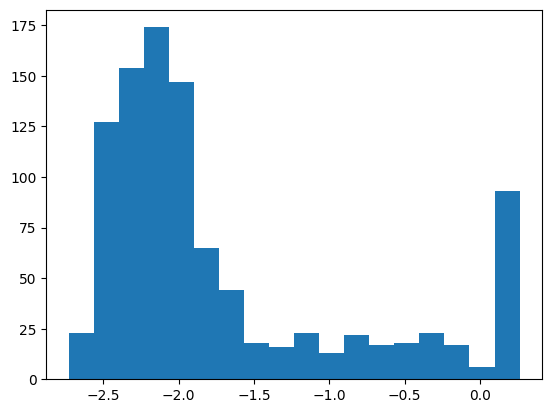

In [11]:
node = cbn.nodes['joint:left_fingers.pos1']

plt.hist(node.observed_y, bins='auto', range=node.limits)
plt.show()

In [40]:
node = cbn.nodes['joint:left_fingers.pos1']

counts, domain = np.histogram(node.observed_y, bins='auto', range=node.limits)
compl_hist = (
    counts.max() - counts,
    domain
)

uncertainty = stats.rv_histogram(compl_hist)

/tmp/ipykernel_16230/2446670198.py:9: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  uncertainty = stats.rv_histogram(compl_hist)


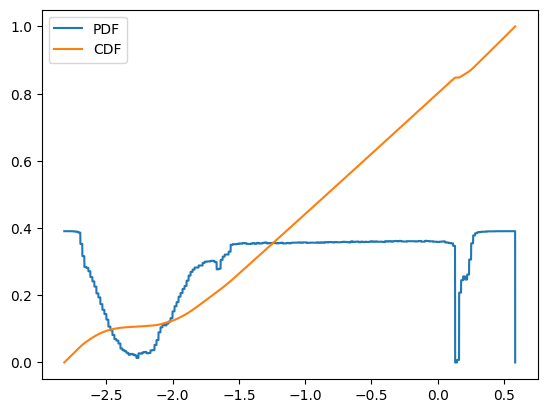

In [41]:
X = np.linspace(node.limits[0], node.limits[1] + 1e-4, int(1e4))
plt.plot(X, uncertainty.pdf(X), label='PDF')
plt.plot(X, uncertainty.cdf(X), label='CDF')
plt.legend()
plt.show()

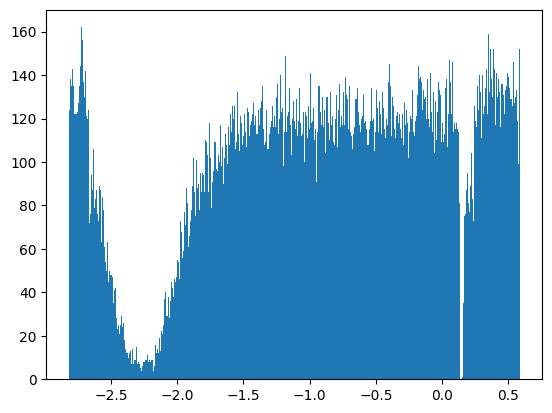

In [42]:
plt.hist(
    x=uncertainty.rvs(size=100_000),
    bins=1000,
    range=node.limits
)
plt.show()

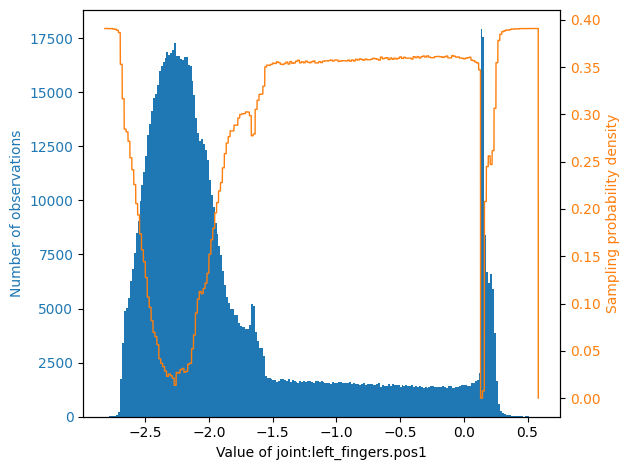

In [43]:
node.plot_obs_distribution()

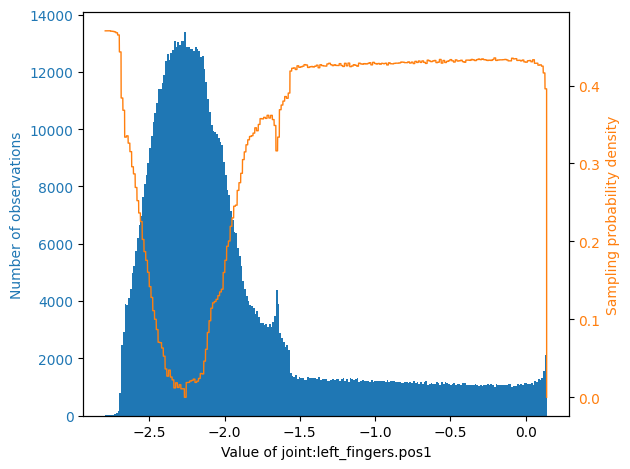

In [24]:
fig, ax1 = plt.subplots()

c1 = 'tab:blue'
c2 = 'tab:orange'

ax1.hist(
    node.observed_y,
    bins='auto',
    range=node.limits,
    color=c1,
)
ax1.set_xlabel(f'Value of {node.name}')
ax1.set_ylabel('Number of observations', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)

ax2 = ax1.twinx()

X = np.linspace(*node.limits, int(1e4))
ax2.plot(
    X,
    node.curiosity.pdf(X),
    color=c2,
    linewidth=1
)
ax2.set_ylabel('Sampling probability density', color=c2)
ax2.tick_params(axis='y', labelcolor=c2)

fig.tight_layout()
plt.savefig('obs_distrib.pdf')

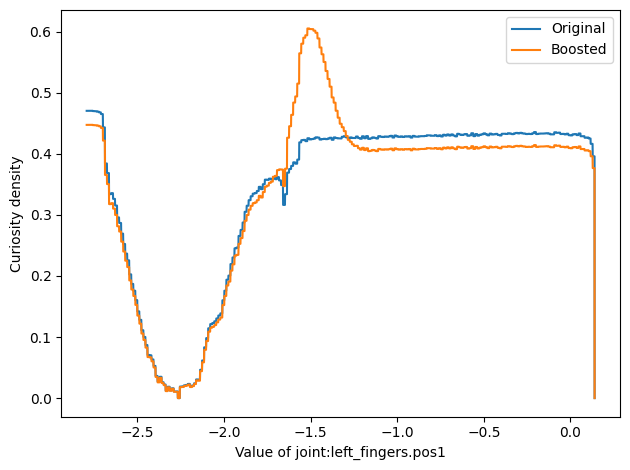

In [25]:
bump_curiosity = node.bump_curiosity(-1.5)

fig, ax = plt.subplots()
ax.plot(X, node.curiosity.pdf(X), label='Original')
ax.plot(X, bump_curiosity.pdf(X), label='Boosted')

ax.set_xlabel(f'Value of {node.name}')
ax.set_ylabel('Curiosity density')

ax.legend()
# plt.show()
plt.tight_layout()
plt.savefig('motivation.pdf')

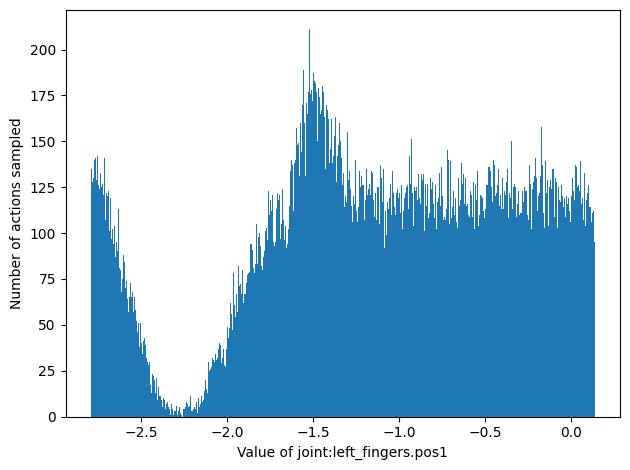

In [26]:
fig, ax = plt.subplots()

ax.hist(
    x=bump_curiosity.rvs(size=100_000),
    bins=1000,
    range=node.limits
)

ax.set_xlabel(f'Value of {node.name}')
ax.set_ylabel('Number of actions sampled')

plt.tight_layout()
# plt.show()
plt.savefig('act-samples.pdf')

### Backtracking

In [44]:
samples = gcm.draw_samples(cbn.M, int(1e7))

In [9]:
target = -1.0
delta = 0.1

mask = np.abs(samples['joint:left_fingers.pos1'] - target) < delta
filtered = samples[mask]

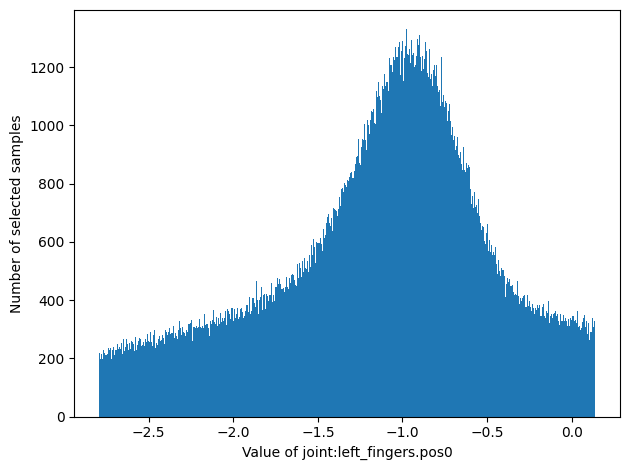

In [10]:
fig, ax = plt.subplots()

ax.hist(filtered['joint:left_fingers.pos0'], bins=1000, range=node.limits)

ax.set_xlabel('Value of joint:left_fingers.pos0')
ax.set_ylabel('Number of selected samples')

plt.tight_layout()
# plt.show()
plt.savefig('selected_left-fingers_pos0.pdf')

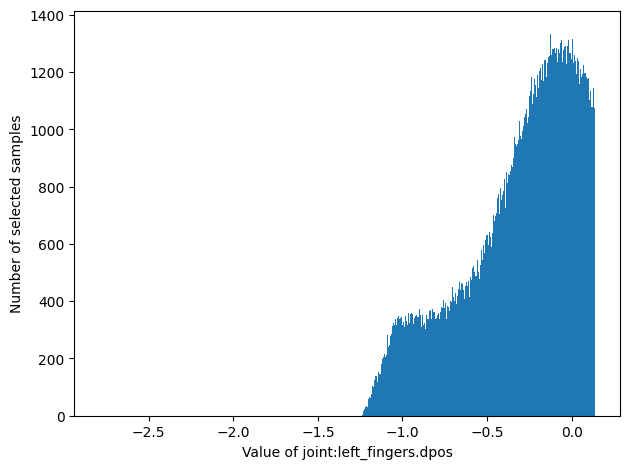

In [11]:
fig, ax = plt.subplots()

ax.hist(filtered['joint:left_fingers.dpos'], bins=1000, range=node.limits)

ax.set_xlabel('Value of joint:left_fingers.dpos')
ax.set_ylabel('Number of selected samples')

plt.tight_layout()
# plt.show()
plt.savefig('selected_left-fingers_dpos.pdf')

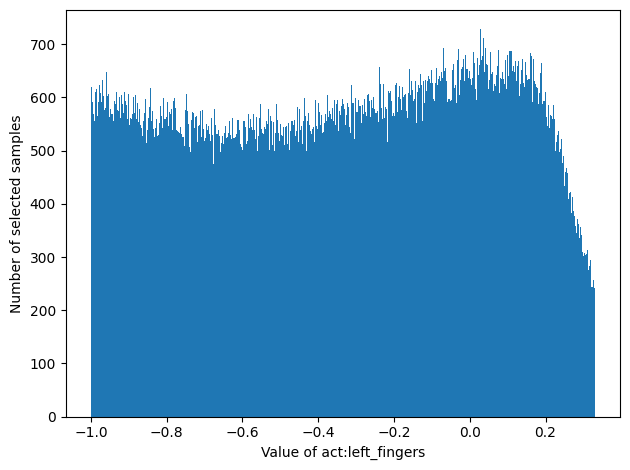

In [12]:
fig, ax = plt.subplots()

ax.hist(filtered['act:left_fingers'], bins=1000, range=act_limits['act:left_fingers'])

ax.set_xlabel('Value of act:left_fingers')
ax.set_ylabel('Number of selected samples')

plt.tight_layout()
# plt.show()
plt.savefig('selected_left-fingers_act.pdf')


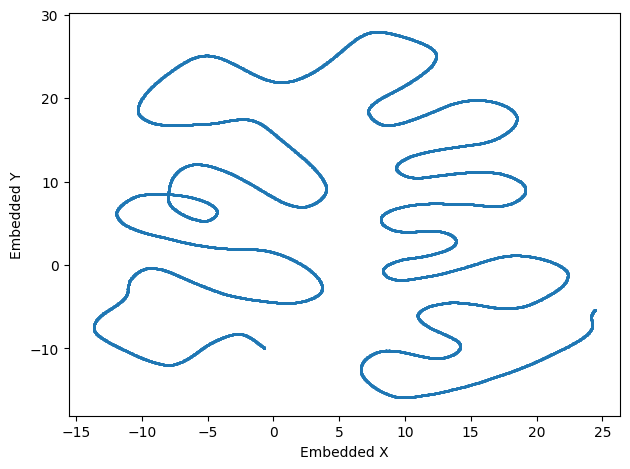

In [13]:
# cbn.nodes['joint:left_fingers.pos1'].plot_image()

node = cbn.nodes['joint:left_fingers.pos1']

X = node.domain
y = node.predict(X)
points = np.hstack((X, y))

dim_reduce = points.shape[1] > 2

if dim_reduce:
    reducer = umap.UMAP(
        n_neighbors=100,
        n_components=2,
        metric='euclidean',
        min_dist=0.1,
        verbose=False
    )
    points = reducer.fit_transform(points)

fig, ax = plt.subplots()
ax.scatter(points[:, 0], points[:, 1], s=1)

if dim_reduce:
    ax.set_xlabel('Embedded X')
    ax.set_ylabel('Embedded Y')
else:
    ax.set_xlabel(f'Ground-truth {node.parents[0].name}')
    ax.set_ylabel(f'Predicted {node.name}')

fig.tight_layout()
# plt.show()
plt.savefig('mapping_left-fingers_pos1.pdf')

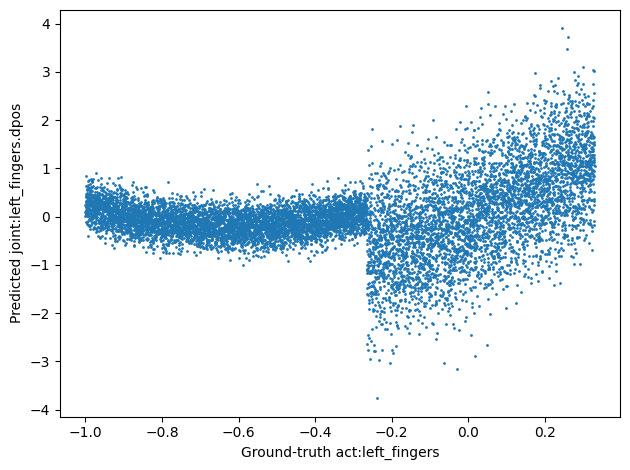

In [45]:
cbn.nodes['joint:left_fingers.dpos'].plot_image()

In [30]:
data_sample = data_proprio.loc[10].to_dict()

for node_name, node_val in data_sample.items():
    lim_min, lim_max = cbn.nodes[node_name].limits

    if node_val < lim_min or node_val > lim_max:
        print(f'{node_name} ({lim_min}, {lim_max}): {node_val}')

joint:right_shoulder_rotation.pos0 (-1.7278759594743862, 1.1693705988362009): -1.7363307476043701
joint:left_shoulder_rotation.pos0 (-1.7278759594743862, 1.1693705988362009): 1.1734737157821655
joint:left_elbow.pos0 (-2.548180707911721, 0.08726646259971647): 0.09790315479040146
joint:left_elbow.dpos (-2.6354471705114375, 2.6354471705114375): -2.663959503173828
joint:right_shoulder_ad_ab.pos1 (-1.4660765716752369, 3.193952531149623): 3.19437313079834
joint:right_shoulder_rotation.pos1 (-1.7278759594743862, 1.1693705988362009): -1.7289824485778809
joint:right_elbow.pos1 (-2.548180707911721, 0.08726646259971647): 0.08891302347183228
joint:left_elbow.pos1 (-2.548180707911721, 0.08726646259971647): -2.566056251525879
joint:left_hand1.pos1 (-1.5707963267948966, 1.5707963267948966): 1.5780093669891357
joint:left_hand3.pos1 (-0.9250245035569946, 0.8377580409572782): 0.84515380859375
joint:left_fingers.pos1 (-2.792526803190927, 0.13962634015954636): 0.22314226627349854


In [46]:
results = cbn.explore(
    state=data_proprio.loc[10].to_dict(),
    fixed_nodes=[
        node_name
        for node_name in cbn.nodes
        if '.pos0' in node_name
    ],
    explored_nodes=[
        node_name
        for node_name in cbn.nodes
        if '.pos1' in node_name
    ],
    readout_nodes=[
        node_name
        for node_name in cbn.nodes
        if 'act:' in node_name
    ],
    delta_gain=1.25,
    min_results=50,
    verbose=True
)

/home/mcibula/Desktop/Projects/sensorimotor-cbn/src/modeling/cbn.py:171: RuntimeWarning: Bin widths are not constant. Assuming `density=True`.Specify `density` explicitly to silence this warning.
  return stats.rv_histogram((boosted_counts, bin_edges))


Starting backpropagated rejection sampling with delta = 0.10
Iteration 1 (delta = 0.10): Failed. Found 0 valid samples, repeating.
Iteration 2 (delta = 0.12): Failed. Found 0 valid samples, repeating.
Iteration 3 (delta = 0.16): Failed. Found 0 valid samples, repeating.
Iteration 4 (delta = 0.20): Failed. Found 0 valid samples, repeating.
Iteration 5 (delta = 0.24): Failed. Found 33 valid samples, repeating.
Iteration 6 (delta = 0.31): Failed. Found 24 valid samples, repeating.
Iteration 7 (delta = 0.38): Failed. Found 14 valid samples, repeating.
Iteration 8 (delta = 0.48): Failed. Found 21 valid samples, repeating.
Iteration 9 (delta = 0.60): Failed. Found 29 valid samples, repeating.
Iteration 10 (delta = 0.75): Failed. Found 38 valid samples, repeating.
Iteration 11 (delta = 0.93): Failed. Found 26 valid samples, repeating.
Iteration 12 (delta = 1.16): Failed. Found 47 valid samples, repeating.
Iteration 13 (delta = 1.46): Failed. Found 36 valid samples, repeating.
Iteration 14 (de

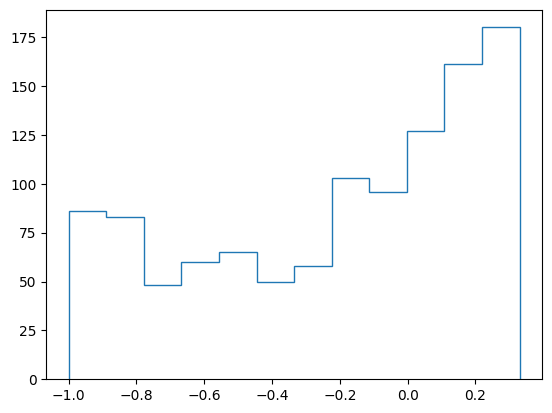

In [47]:
counts, bins = results['act:left_fingers']._histogram

plt.stairs(counts, bins)
plt.show()

### Misc

In [28]:
# with open('./models/proprio_cbn.pkl', 'rb') as f:
#     proprio_M: InvertibleStructuralCausalModel = pickle.load(f)
#     proprio_G: DiGraph = proprio_M.graph